In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import regex
from sklearn.preprocessing import OrdinalEncoder
from skfeature.function.similarity_based.fisher_score import fisher_score
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, log_loss, make_scorer, RocCurveDisplay

In [39]:
train_data = pd.read_csv('./data/train.csv',index_col=0)

train_data.info()

train_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [40]:
test_data = pd.read_csv('./data/test_augmented.csv',index_col=0)

test_data.info()

test_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
 10  Survived  418 non-null    int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 39.2+ KB


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
PassengerId,,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1


In [41]:
# Eliminiamo la colonna Cabin perché è troppo sparsa
train_data.drop('Cabin',axis=1,inplace=True)

test_data.drop('Cabin',axis=1,inplace=True)

train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 76.6+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    i

In [42]:
# Contiamo i valori assunti da Embarked
train_data.groupby('Embarked').count()['Survived']

Embarked
C    168
Q     77
S    644
Name: Survived, dtype: int64

In [43]:
# Imputiamo a maggioranza i valori nulli di Embarked
train_data['Embarked'].fillna(train_data.groupby('Embarked').count()['Survived'].idxmax(), inplace=True)

In [44]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 76.6+ KB


In [45]:
# Aggiungiamo una colonna "Title" al dataframe per riportare il titolo estratto con regexp
train_data.insert(3, 'Title', train_data['Name'].apply(lambda x: regex.search(r'.*, (.*?)\. .*',x).group(1)))

train_data

,Survived,Pclass,Name,Title,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",Mr,male,22.0,1,0,A/5 21171,7.2500,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,female,38.0,1,0,PC 17599,71.2833,C
3,1,3,"Heikkinen, Miss. Laina",Miss,female,26.0,0,0,STON/O2. 3101282,7.9250,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,female,35.0,1,0,113803,53.1000,S
5,0,3,"Allen, Mr. William Henry",Mr,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",Rev,male,27.0,0,0,211536,13.0000,S
888,1,1,"Graham, Miss. Margaret Edith",Miss,female,19.0,0,0,112053,30.0000,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",Miss,female,NaN,1,2,W./C. 6607,23.4500,S


In [46]:
avg_age = pd.DataFrame(train_data.groupby(['Title'])['Age'].mean())

avg_age.rename(columns={"Age": "Avg_age"}, inplace=True)

avg_age

,Avg_age
Title,
Capt,70.000000
Col,58.000000
Don,40.000000
Dr,42.000000
Jonkheer,38.000000
Lady,48.000000
Major,48.500000
Master,4.574167
Miss,21.773973


In [47]:
# Inner join tra train_data e avg_age

train_data = train_data.join(avg_age, how='inner', on='Title', rsuffix='_avg', validate='m:1')

train_data

,Survived,Pclass,Name,Title,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Avg_age
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",Mr,male,22.0,1,0,A/5 21171,7.2500,S,32.36809
5,0,3,"Allen, Mr. William Henry",Mr,male,35.0,0,0,373450,8.0500,S,32.36809
6,0,3,"Moran, Mr. James",Mr,male,NaN,0,0,330877,8.4583,Q,32.36809
7,0,1,"McCarthy, Mr. Timothy J",Mr,male,54.0,0,0,17463,51.8625,S,32.36809
13,0,3,"Saundercock, Mr. William Henry",Mr,male,20.0,0,0,A/5. 2151,8.0500,S,32.36809
...,...,...,...,...,...,...,...,...,...,...,...,...
648,1,1,"Simonius-Blumer, Col. Oberst Alfons",Col,male,56.0,0,0,13213,35.5000,C,58.00000
695,0,1,"Weir, Col. John",Col,male,60.0,0,0,113800,26.5500,S,58.00000
746,0,1,"Crosby, Capt. Edward Gifford",Capt,male,70.0,1,1,WE/P 5735,71.0000,S,70.00000


In [48]:
# Eseguiamo l'imputazione con i valori di età media sulla stessa riga del valore nullo

train_data['Age'].fillna(train_data['Avg_age'], inplace=True)

train_data.info()

train_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 823
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Title     891 non-null    object 
 4   Sex       891 non-null    object 
 5   Age       891 non-null    float64
 6   SibSp     891 non-null    int64  
 7   Parch     891 non-null    int64  
 8   Ticket    891 non-null    object 
 9   Fare      891 non-null    float64
 10  Embarked  891 non-null    object 
 11  Avg_age   891 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 90.5+ KB


,Survived,Pclass,Name,Title,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Avg_age
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",Mr,male,22.00000,1,0,A/5 21171,7.2500,S,32.36809
5,0,3,"Allen, Mr. William Henry",Mr,male,35.00000,0,0,373450,8.0500,S,32.36809
6,0,3,"Moran, Mr. James",Mr,male,32.36809,0,0,330877,8.4583,Q,32.36809
7,0,1,"McCarthy, Mr. Timothy J",Mr,male,54.00000,0,0,17463,51.8625,S,32.36809
13,0,3,"Saundercock, Mr. William Henry",Mr,male,20.00000,0,0,A/5. 2151,8.0500,S,32.36809


In [49]:
# Eseguiamo il drop della colonna 'Avg_age'

train_data.drop('Avg_age', axis=1, inplace=True)

In [50]:
# Facciamo l'imputazioen anche per il test set

test_data.insert(3, 'Title', test_data['Name'].apply(lambda x: regex.search(r'.*, (.*?)\. .*',x).group(1)))

test_avg_age = pd.DataFrame(test_data.groupby(['Title'])['Age'].mean())

test_avg_age.rename(columns={"Age": "Avg_age"}, inplace=True)

test_data = test_data.join(test_avg_age, how='inner', on='Title', rsuffix='_avg', validate='m:1')

test_data['Age'].fillna(test_data['Avg_age'], inplace=True)

test_data.info()

test_data.drop('Avg_age', axis=1, inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1306
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Title     418 non-null    object 
 4   Age       417 non-null    float64
 5   SibSp     418 non-null    int64  
 6   Parch     418 non-null    int64  
 7   Ticket    418 non-null    object 
 8   Fare      417 non-null    float64
 9   Embarked  418 non-null    object 
 10  Survived  418 non-null    int64  
 11  Avg_age   417 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 42.5+ KB


In [51]:
test_avg_age

,Avg_age
Title,
Col,50.000000
Dona,39.000000
Dr,53.000000
Master,7.406471
Miss,21.774844
Mr,32.000000
Mrs,38.903226
Ms,NaN
Rev,35.500000


In [52]:
# C'è un'unica passeggera con titolo 'Ms' con età nulla
test_data[test_data['Title'] == 'Ms']

,Pclass,Name,Sex,Title,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
PassengerId,,,,,,,,,,,
980,3,"O'Donoghue, Ms. Bridget",female,Ms,NaN,0,0,364856,7.75,Q,0


In [53]:
test_data.loc[980, 'Age'] = test_avg_age.loc['Miss','Avg_age']

test_data[test_data['Title'] == 'Ms']

,Pclass,Name,Sex,Title,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
PassengerId,,,,,,,,,,,
980,3,"O'Donoghue, Ms. Bridget",female,Ms,21.774844,0,0,364856,7.75,Q,0


In [54]:
test_data[test_data['Fare'].isna()]

,Pclass,Name,Sex,Title,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
PassengerId,,,,,,,,,,,
1044,3,"Storey, Mr. Thomas",male,Mr,60.5,0,0,3701,NaN,S,0


In [55]:
avg_fare = pd.DataFrame(test_data.groupby('Pclass')['Fare'].mean())

avg_fare

,Fare
Pclass,
1,94.280297
2,22.202104
3,12.459678


In [56]:
test_data.loc[1044, 'Fare'] = avg_fare.loc[3, 'Fare']

In [57]:
test_data.loc[1044]

Pclass                       3
Name        Storey, Mr. Thomas
Sex                       male
Title                       Mr
Age                       60.5
SibSp                        0
Parch                        0
Ticket                    3701
Fare                 12.459678
Embarked                     S
Survived                     0
Name: 1044, dtype: object

In [58]:
# Effettuiamo l'ncoding delle feature categoriche

enc = OrdinalEncoder()

sex_enc = enc.fit_transform(train_data['Sex'].to_numpy().reshape(-1, 1))

emb_enc = enc.fit_transform(train_data['Embarked'].to_numpy().reshape(-1, 1))

In [59]:
# Inseriamo le nuove colonne dei dati codificati

train_data.insert(2, 'Sex_enc', sex_enc)
train_data.insert(3, 'Emb_enc', emb_enc)

train_data

,Survived,Pclass,Sex_enc,Emb_enc,Name,Title,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
PassengerId,,,,,,,,,,,,,
1,0,3,1.0,2.0,"Braund, Mr. Owen Harris",Mr,male,22.00000,1,0,A/5 21171,7.2500,S
5,0,3,1.0,2.0,"Allen, Mr. William Henry",Mr,male,35.00000,0,0,373450,8.0500,S
6,0,3,1.0,1.0,"Moran, Mr. James",Mr,male,32.36809,0,0,330877,8.4583,Q
7,0,1,1.0,2.0,"McCarthy, Mr. Timothy J",Mr,male,54.00000,0,0,17463,51.8625,S
13,0,3,1.0,2.0,"Saundercock, Mr. William Henry",Mr,male,20.00000,0,0,A/5. 2151,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
648,1,1,1.0,0.0,"Simonius-Blumer, Col. Oberst Alfons",Col,male,56.00000,0,0,13213,35.5000,C
695,0,1,1.0,2.0,"Weir, Col. John",Col,male,60.00000,0,0,113800,26.5500,S
746,0,1,1.0,2.0,"Crosby, Capt. Edward Gifford",Capt,male,70.00000,1,1,WE/P 5735,71.0000,S


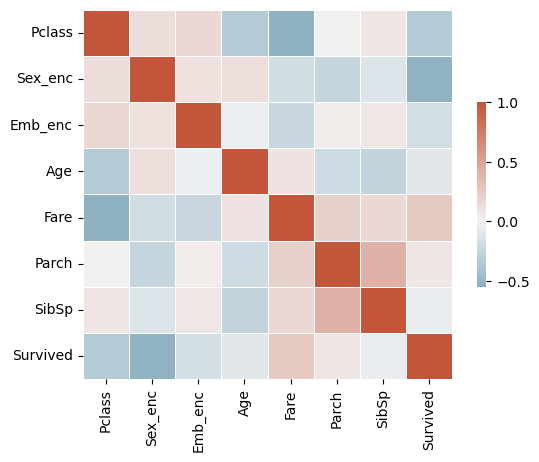

In [60]:
corr = train_data[['Pclass', 'Sex_enc', 'Emb_enc', 'Age', 'Fare', 'Parch', 'SibSp', 'Survived']].corr()

# Disegniamo la matrice

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, cmap=cmap, center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.5})

plt.show()

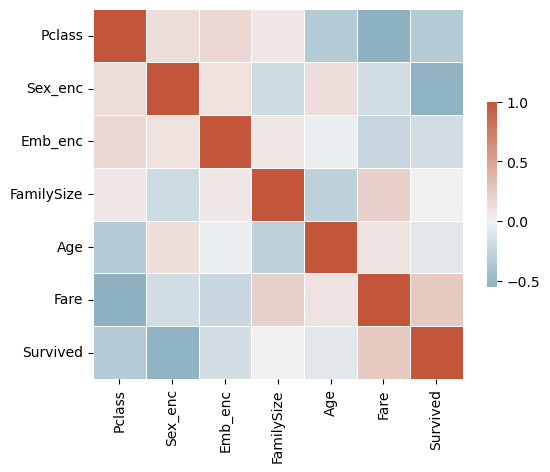

In [61]:
# Inseriamo la colonna FamilySize = Parch + Sibsp + 1

train_data.insert(4,'FamilySize',train_data[['Parch','SibSp']].apply(lambda x: np.sum(x)+1, axis=1))

# Creiamo la nuova matrice di correlazione

corr = train_data[['Pclass', 'Sex_enc', 'Emb_enc', 'FamilySize', 'Age', 'Fare', 'Survived']].corr()

# Disegniamo la matrice

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, cmap=cmap, center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.5})

plt.show()




In [62]:
# Creiamo il data set in formato numpy

X = train_data[['Pclass', 'Sex_enc', 'Emb_enc', 'FamilySize', 'Age', 'Fare']].to_numpy()

y = train_data['Survived'].to_numpy()

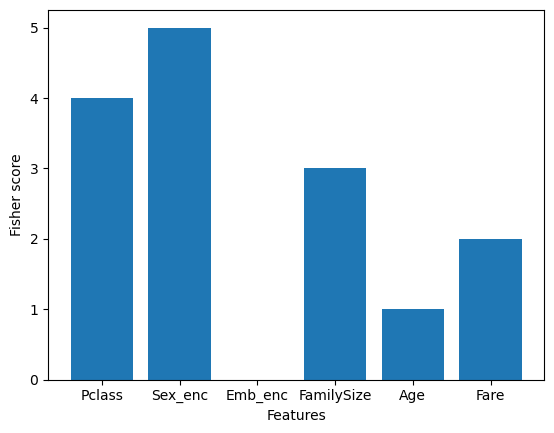

In [63]:
# Effettuiamo la feature selection con il Fisher score

fisher_ranks = SelectKBest(fisher_score, k=6).fit(X,y)

scores = fisher_ranks.scores_

plt.bar(['Pclass', 'Sex_enc', 'Emb_enc', 'FamilySize', 'Age', 'Fare'], scores)

plt.xlabel('Features')
plt.ylabel('Fisher score')
plt.show()

In [64]:
# Selezioniamo le prime 5 feature eliminando Emb_enc

X_new = SelectKBest(fisher_score, k=5).fit_transform(X, y)

In [ ]:
# Split di training set a fini di validazione dell'addestramento
# perché il vero test set è **senza** label

# Lo split a questo punto soffre di data leakage prché le stime statistiche dell'età ovvero del porto di imbarco
# sono state fatte sul training set tutto insieme

X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.1, random_state=42)

# Griglia degli iperparametri per l'algoritmo di Gradient Boosting

params = {
    "n_estimators": [200],
    "validation_fraction": [0.05, 0.075, 0.1],
    "n_iter_no_change": [10],
    "tol": [0.01],
    "max_depth": [None],
    "subsample": [0.5, 0.67, 0.8],
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "min_samples_leaf": [1],
    "random_state": [42]
}

scoring = {
    'Accuracy': make_scorer(accuracy_score),
    'F1': make_scorer(f1_score),
    'Bal. Acc.': make_scorer(balanced_accuracy_score),
    'Log_loss': make_scorer(log_loss, greater_is_better=False, needs_proba=True)
}

grid = GridSearchCV(
    estimator=GradientBoostingClassifier(),
    param_grid=params,
    scoring=scoring,
    return_train_score=True,
    cv=None,
    refit='Accuracy'
)

grid.fit(X_train, y_train)

classifier = grid.best_estimator_

In [68]:
hyper = classifier.get_params()

In [69]:
hyper

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.05,
 'loss': 'log_loss',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 200,
 'n_iter_no_change': 10,
 'random_state': 42,
 'subsample': 0.5,
 'tol': 0.01,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [70]:
print(f'Training accuracy: {grid.best_score_:5.4f}')

Training accuracy: 0.8190


In [73]:
# Creiamo il plot delle metriche
def display_metrics_ROC(X_test, y_test):
    epochs = np.arange(classifier.n_estimators_) + 1
    
    metric_labels = ['log-loss', 'f1 score', 'accuracy', 'bal. acc.']
    
    metrics = np.zeros((4, classifier.n_estimators_), dtype=np.float64)
    
    for i, y_proba in enumerate(classifier.staged_predict_proba(X_test)):
        metrics[0, i] = log_loss(y_test, y_proba[:, 1])
    
    for i, y_class in enumerate(classifier.staged_predict(X_test)):
        metrics[1, i] = f1_score(y_test, y_class)
        metrics[2, i] = accuracy_score(y_test, y_class)
        metrics[3, i] = balanced_accuracy_score(y_test, y_class)
    
    metrics_strings = f'Log loss: {metrics[0, -1]:5.4f}\nF1: {metrics[1, -1]:5.4f}\nAcc: {metrics[2, -1]:5.4f}\nBal Acc: {metrics[3, -1]:5.4f}'
    
    plt.plot(epochs, metrics[0], '-', color='red', label=metric_labels[0])
    plt.plot(epochs, metrics[1], '-', color='orange', label=metric_labels[1])
    plt.plot(epochs, metrics[2], '-', color='turquoise', label=metric_labels[2])
    plt.plot(epochs, metrics[3], '-', color='green', label=metric_labels[3])
    
    plt.xlabel('Boosting epochs')
    plt.ylabel('Metrics')
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.02))
    plt.text(34, 0.0, metrics_strings)
    
    plt.show()
    
    # Mostriamo la Curva ROC
    
    RocCurveDisplay.from_estimator(classifier, X_test, y_test)
    
    plt.show()


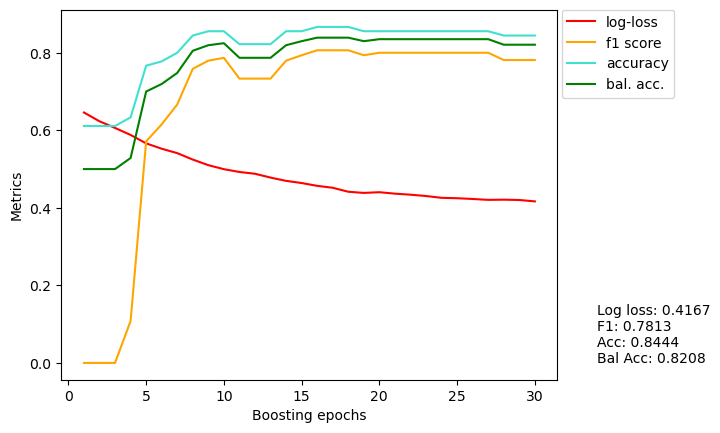

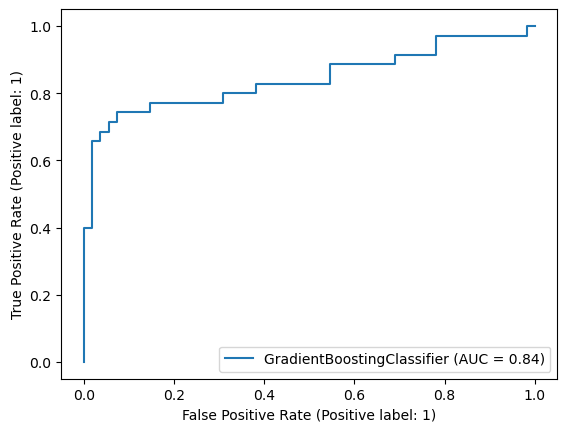

In [74]:
display_metrics_ROC(X_test, y_test)

In [75]:
# Creiamo il vettore delle feature anche per il test set annotato della competizione

# Codifichiamo la feature categorica Sex
sex_enc = enc.fit_transform(test_data['Sex'].to_numpy().reshape(-1, 1))
test_data.insert(2, 'Sex_enc', sex_enc)

# Inseriamo la colonna FamilySize = Parch + Sibsp + 1
test_data.insert(4,'FamilySize',test_data[['Parch','SibSp']].apply(lambda x: np.sum(x)+1, axis=1))

# Creiamo il test set per la competizione
X_test_comp = test_data[['Pclass', 'Sex_enc', 'FamilySize', 'Age', 'Fare']].to_numpy()

y_test_comp = test_data['Survived'].to_numpy()



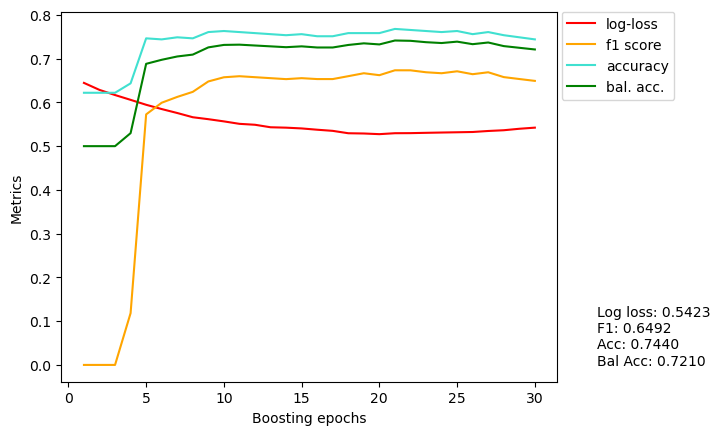

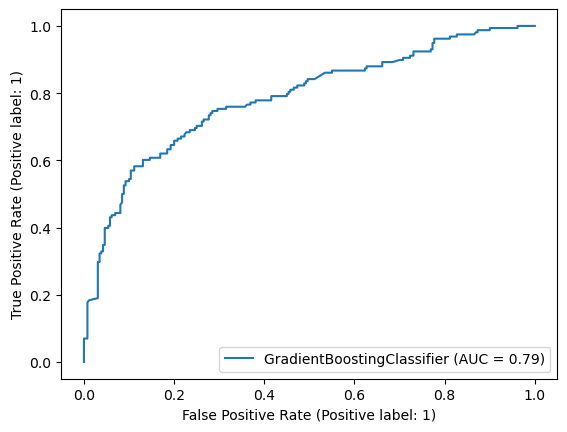

In [76]:
# Mostriamo le metriche per il test set della competizione
display_metrics_ROC(X_test_comp, y_test_comp)